# Esercitazione 30 Marzo 2026

# Metodi di approssimazione degli zeri di una funzione non lineare

Si richiede di scrivere le funzioni Python `bisezione.py`, `falsi.py`, `corde.py`, `secanti.py` e `newton.py`, che implementino rispettivamente il metodo di **bisezione**, di **falsa posizione**, delle **corde**, delle **secanti** e di **Newton** per l’approssimazione di uno zero di una funzione non lineare.

---

## 📌 Metodi di bisezione e falsa posizione

Le funzioni `bisezione.py` e `falsi.py` devono assumere in input:

- gli estremi `a` e `b` di un intervallo $[a,b]$ contenente uno zero della funzione;
- il nome `fname` della funzione di cui si vuole approssimare uno zero;
- `tolx`: tolleranza per il test di arresto basato sull’errore relativo tra due iterati successivi;
- `tolf`: tolleranza per il test di arresto basato sul valore assoluto della funzione;
- `nmax`: numero massimo di iterazioni consentite.

---


## 📌 Metodo delle corde

La funzione `corde.py` deve assumere in input:

- un valore iniziale `x0`;
- il nome `fname` della funzione di cui si vuole approssimare uno zero;
- il valore `m`, coefficiente angolare costante della retta  oppure fissato a priori);
- `tolx`: tolleranza per il test di arresto basato sull’errore relativo tra due iterati successivi;
- `tolf`: tolleranza per il test di arresto basato sul valore assoluto della funzione;
- `nmax`: numero massimo di iterazioni consentite.

---

## 📌 Metodo di Newton

La funzione `newton.py` deve assumere in input:

- un valore iniziale `x0`;
- il nome `fname` della funzione di cui si vuole approssimare uno zero;
- il nome `fpname` della derivata prima di `fname`;
- `tolx`: tolleranza per il test di arresto basato sull’errore relativo tra due iterati successivi;
- `tolf`: tolleranza per il test di arresto basato sul valore assoluto della funzione;
- `nmax`: numero massimo di iterazioni consentite.

---
## 📌 Metodo delle secanti

La funzione `secanti.py` deve assumere in input:

- due valori iniziali `x0` e `x1`;
- il nome `fname` della funzione di cui si vuole approssimare uno zero;
- `tolx`: tolleranza per il test di arresto basato sull’errore relativo tra due iterati successivi;
- `tolf`: tolleranza per il test di arresto basato sul valore assoluto della funzione;
- `nmax`: numero massimo di iterazioni consentite.

---

## 📤 Output richiesto

Tutte le funzioni devono restituire:

- un’approssimazione dello zero della funzione;
- il numero di iterazioni effettuate;
- una lista contenente tutti gli iterati $x_k$ prodotti dal metodo.

# 🔬 Funzioni test

Per verificare il corretto funzionamento dei metodi implementati, si considerano diverse funzioni test, scelte in modo da evidenziare differenti comportamenti numerici.

---

## ⭐ Funzione test principale

$$ f(x)=x^4-9x^2+4x+12 $$

Si chiede di:

- analizzando il grafico determinare il numero di zeri della funzione nell’intervallo assegnato, specificandone la molteplicità per ciascuno di essi (fare uso della definizione di molteplicità di uno zero);
- approssimare tali zeri mediante i metodi di Bisezione, Falsa Posizione, Corde, Secanti e Newton, scegliendo opportunamente, per ciascun metodo, il valore iniziale dell’iterazione, e determinarne l’ordine di convergenza;
- nel caso in cui il metodo di Newton presenti ordine di convergenza pari a 1, implementare il metodo di Newton modificato e verificare che l’ordine di convergenza diventi quadratico.

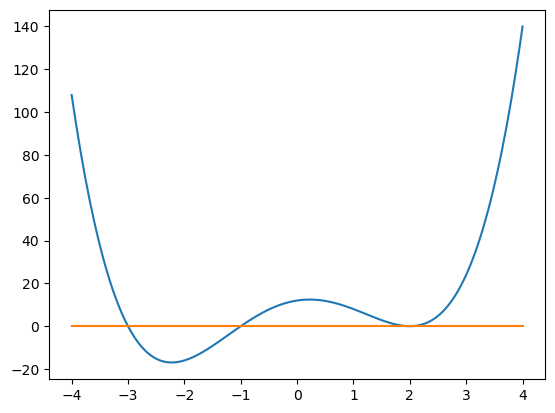

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
import zeri_funzione as zeri

x = sym.symbols('x')
fs = x**4 - 9*x**2 + 4*x + 12
a = -4
b = 4
xx = np.linspace(a, b, 200)
f = sym.lambdify(x, fs, np)
plt.plot(xx, f(xx), xx, np.zeros_like(xx))

In [2]:
def molteciplita_zero(f, alpha, max_order = 10):
    x = sym.symbols('x')
    for m in range(max_order + 1):
        derivata = sym.diff(f, x, m)
        if derivata.subs(x, alpha) != 0:
            return m
    return None

In [3]:
alpha1 = -3
alpha2 = -1
alpha3 = 2
m1 = molteciplita_zero(fs, alpha1)
m2 = molteciplita_zero(fs, alpha1)
m3 = molteciplita_zero(fs, alpha1)
print("Lo zero ", alpha1, "ha molteplicità", m1)
print("Lo zero ", alpha2, "ha molteplicità", m2)
print("Lo zero ", alpha3, "ha molteplicità", m3)

Lo zero  -3 ha molteplicità 1
Lo zero  -1 ha molteplicità 1
Lo zero  2 ha molteplicità 1


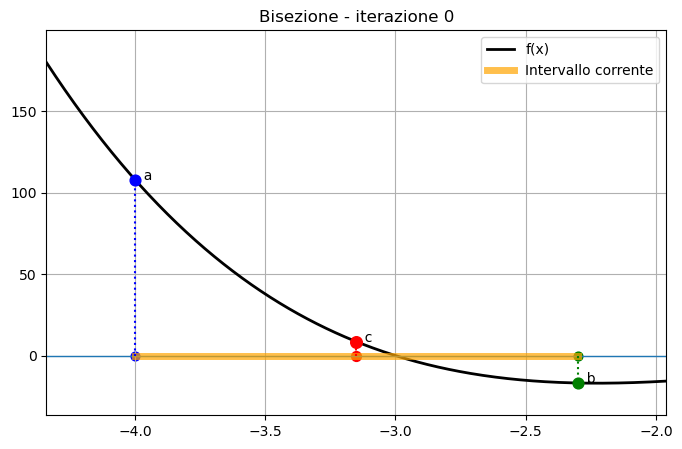

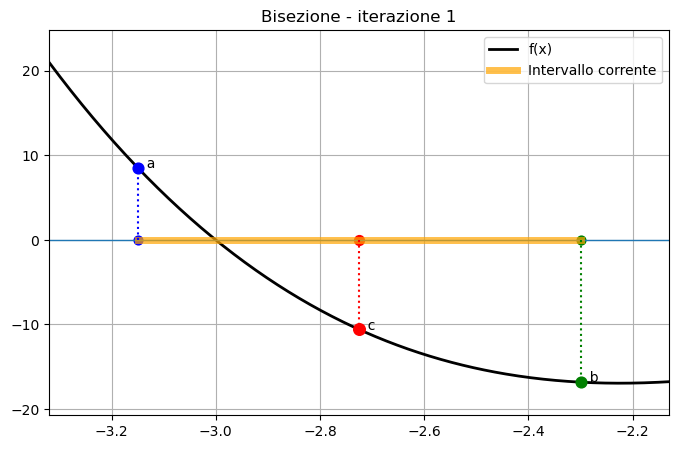

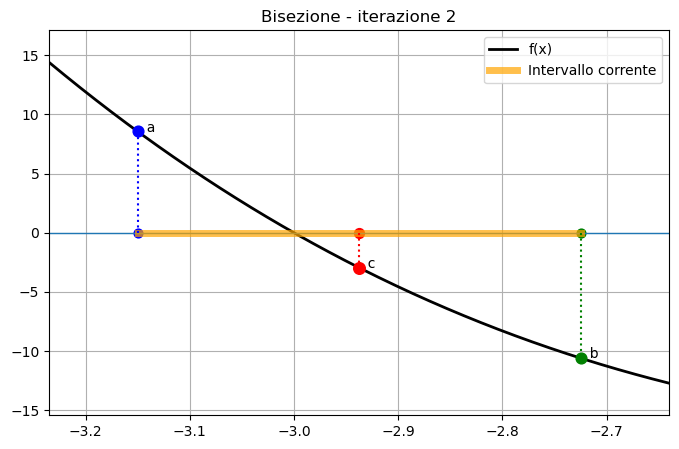

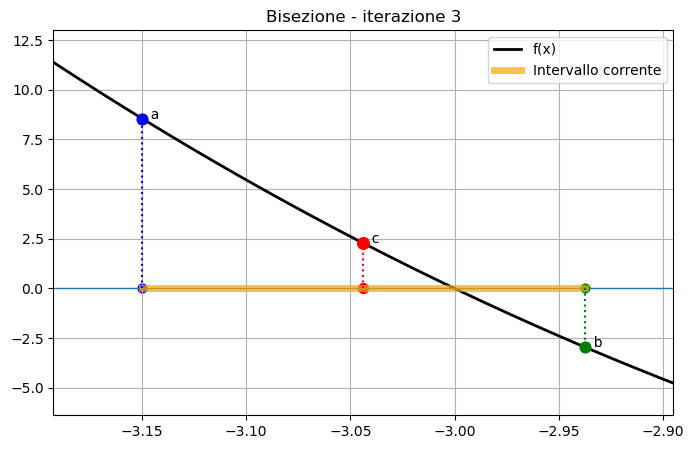

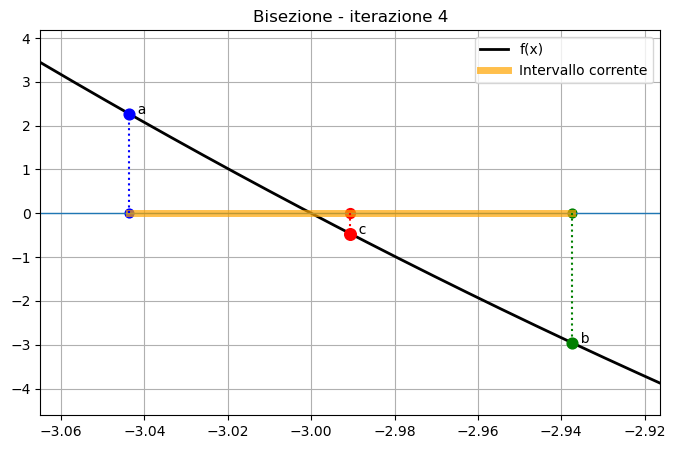

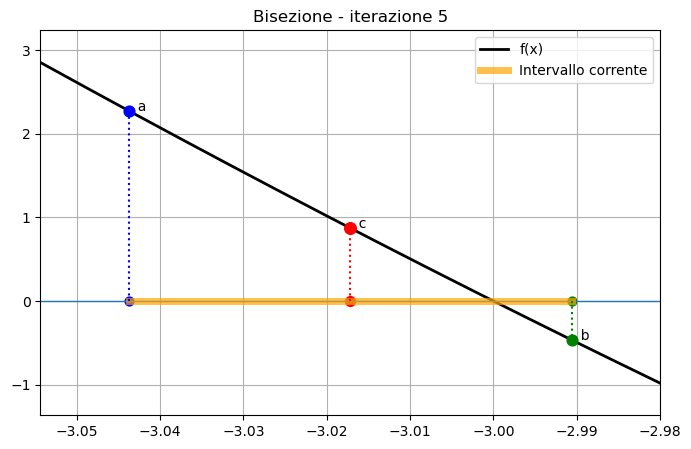

Primo zero bisezione  -3.0000000026077034  numero di iterazioni  28
[1.50000000e-01 2.75000000e-01 6.25000000e-02 4.37500000e-02
 9.37500000e-03 1.71875000e-02 3.90625000e-03 2.73437500e-03
 5.85937500e-04 1.07421875e-03 2.44140625e-04 1.70898438e-04
 3.66210937e-05 6.71386719e-05 1.52587891e-05 1.06811523e-05
 2.28881836e-06 4.19616699e-06 9.53674316e-07 6.67572022e-07
 1.43051147e-07 2.62260437e-07 5.96046448e-08 4.17232515e-08
 8.94069663e-09 1.63912777e-08 3.72529030e-09 2.60770339e-09]


In [4]:
tolx = 1e-12
tolf = 1e-12
a1 = -4.0
b1 = -2.3
zero1_b, it1_b, xk_1_b = zeri.metodo_di_bisezione(f, a1, b1, tolx, tolf)
print("Primo zero bisezione ", zero1_b, " numero di iterazioni ", it1_b)
ek_1_b = np.abs(xk_1_b - alpha1)
print(ek_1_b)

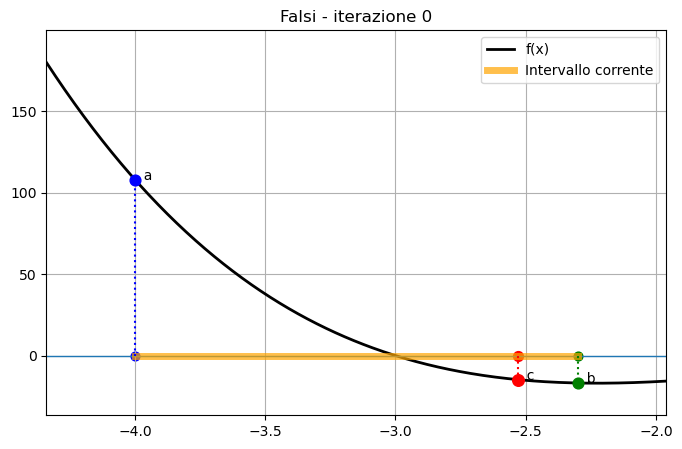

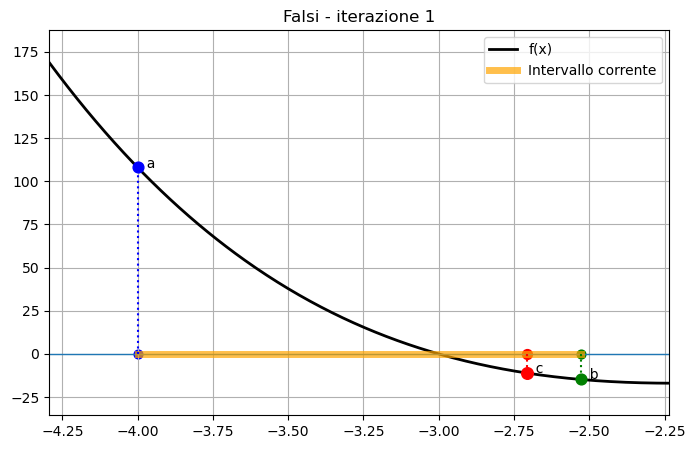

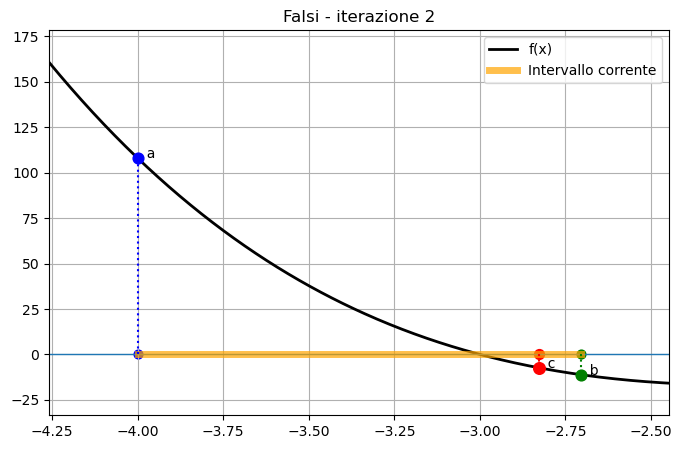

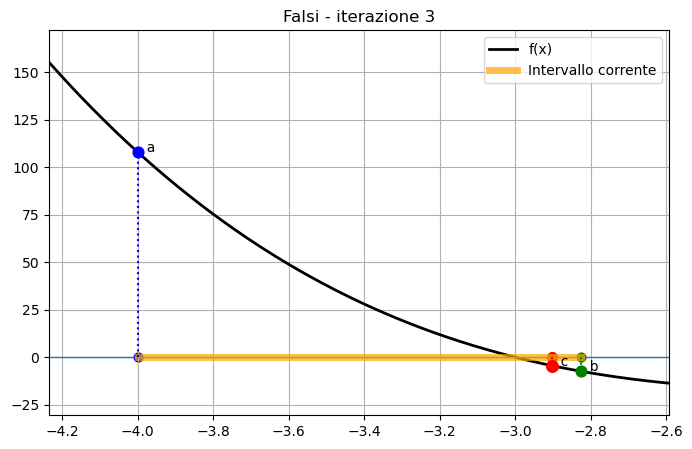

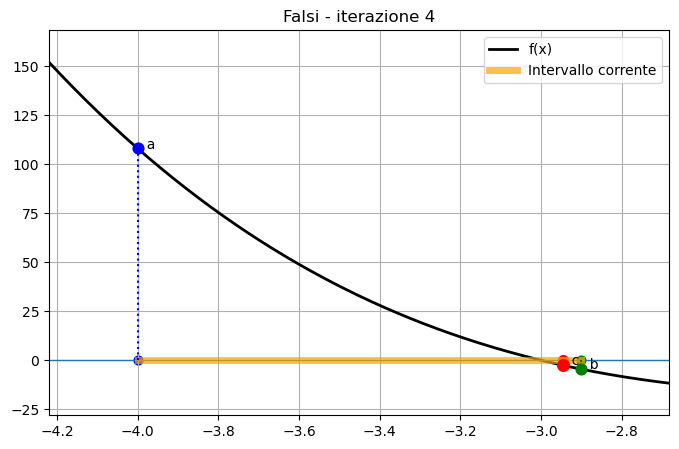

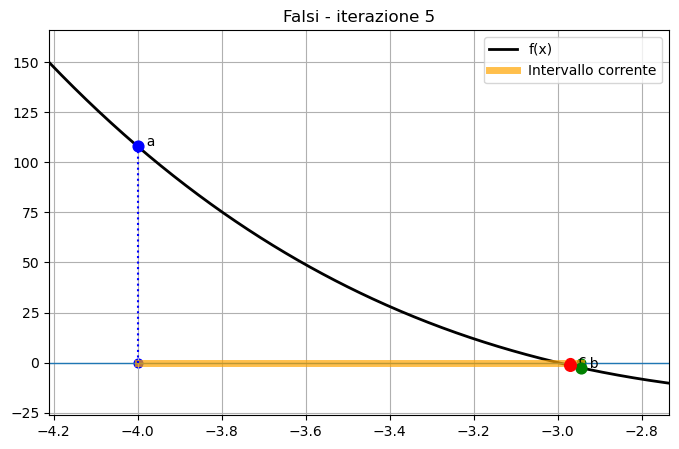

In [5]:
max_it = 50
zero1_f, it1_f, xk1_f = zeri.falsi(f, a1, b1, tolx, tolf, max_it)

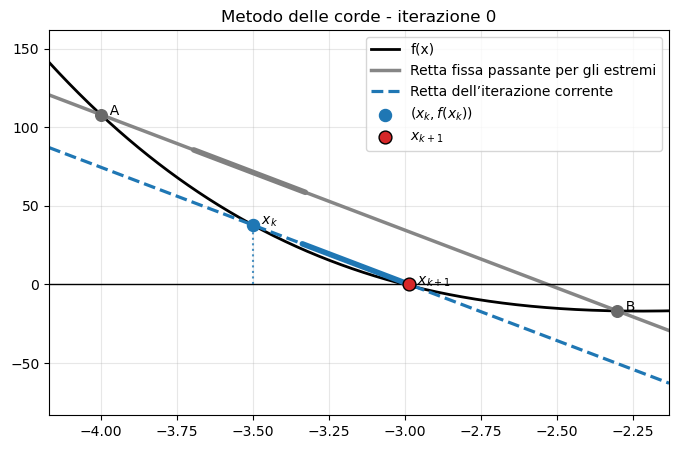

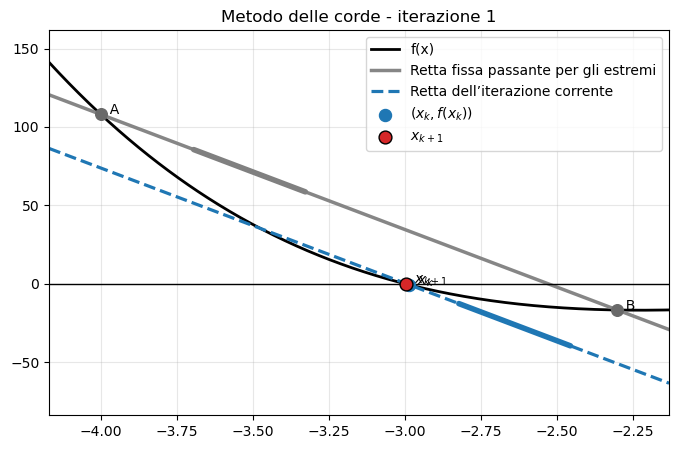

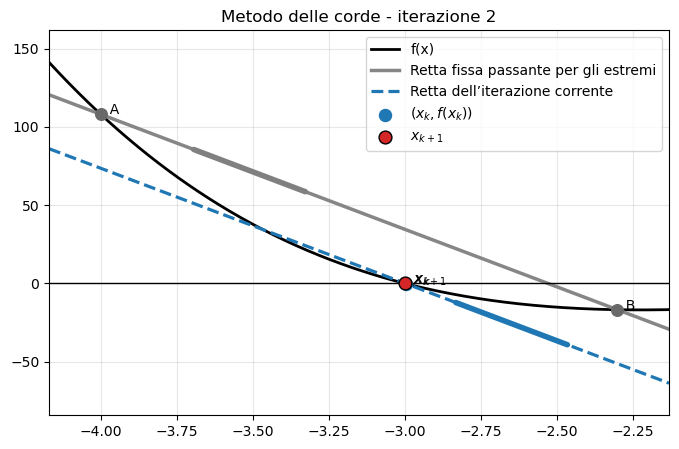

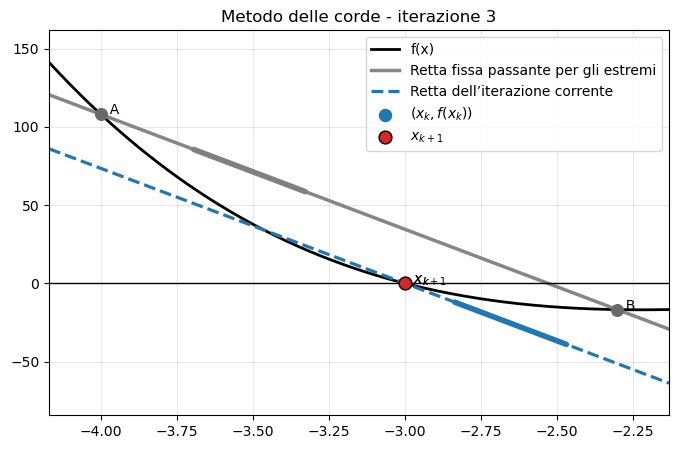

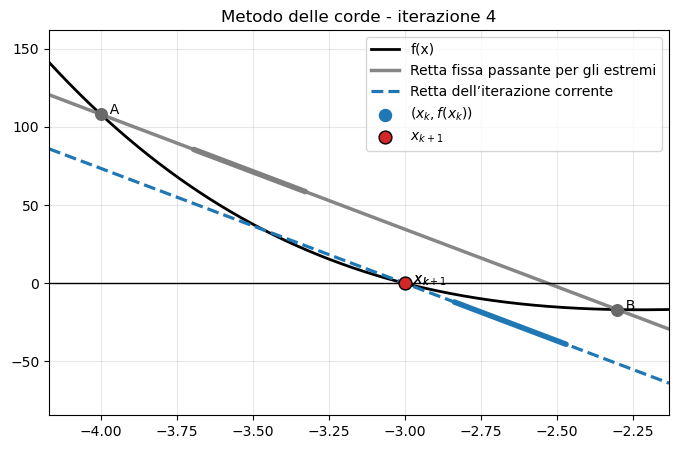

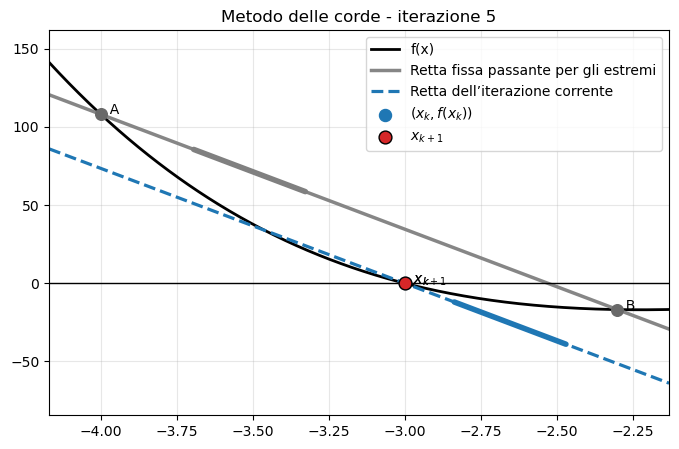

NameError: name 'xk' is not defined

In [9]:
coeff_ang = (f(b1) - f(a1)) / (b1 - a1)
x0 = -3.5
zero1_f, it1_f, xk1_f = zeri.corde(f, a1, b1, x0, coeff_ang, tolx, tolf, max_it)

 ## 🔬 Altre Funzioni test
 Confrontare tutti i metodi implementati (bisezione, falsa posizione, corde, secanti, Newton) nei casi seguenti:
- f(x) = $x^3-6x^2-4x+24$ in [-3,8], tolx = 1.e − 12, tolf = 1.e − 12, (soluzione esatta alfa=-2,2,6);
- f(x) = exp(−x) − (x + 1) in [−1, 2]  tolx = 1.e − 12, tolf = 1.e − 12, (soluzione esatta alfa=0);
- f(x) = log2(x + 3) − 2 in [−1, 2]  tolx = 1.e − 12, tolf = 1.e − 12, (soluzione esatta alfa=1);
- f(x) =sqrt(x)-(x^2)/4 in [1, 3]  tolx = 1.e − 12, tolf =1.e − 12, (soluzione esatta alfa=2**(4/3))

Mostrare in un grafico in scala semilogaritmica sulle ordinate (comando semilogy) l’andamento di ek = |xk − α|, k = 1, ..., nit, sapendo che α = 0, 1, 2**(4/3) nei casi 2-4.

Calcolare l'ordine di ciascun metodo.


## Problema
Utilizzare il metodo di bisezione ed il metodo di Newton per calcolare la radice quadrata di 5. Analizzate i risultati.